In [60]:
from sklearn.calibration import CalibratedClassifierCV
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, 
    precision_recall_curve, average_precision_score, confusion_matrix, classification_report
)

In [61]:
FEATURES_DIR = 'C:\\Users\\atogni\\Desktop\\rongowai\\deliver\\processed_data'

In [62]:
# Load extracted features from Parquet
fit_data_with_features_df = pd.read_parquet(f"{FEATURES_DIR}/compressed_fit_features.parquet")
fit_labels_clean_df = pd.read_parquet(f"{FEATURES_DIR}/compressed_fit_labels.parquet")
fit_labels_clean = fit_labels_clean_df['label'].values

test_data_with_features_df = pd.read_parquet(f"{FEATURES_DIR}/compressed_test_features.parquet")
test_labels_clean_df = pd.read_parquet(f"{FEATURES_DIR}/compressed_test_labels.parquet")
test_labels_clean = test_labels_clean_df['label'].values

FEATURES = fit_data_with_features_df.columns.tolist()

In [63]:
fit_data_with_features_df = pd.DataFrame(fit_data_with_features_df, columns=FEATURES)
test_data_with_features_df = pd.DataFrame(test_data_with_features_df, columns=FEATURES)

In [64]:

model_path = "C:\\Users\\atogni\\Desktop\\rongowai\\deliver\\xgboost_compressed_with_features_021025_0956_delivery\\models\\xgboost_compressed_with_features_021025_0956_delivery_final_run_021025_0956.joblib"
scaler_path = 'C:\\Users\\atogni\\Desktop\\rongowai\\deliver\\xgboost_compressed_with_features_021025_0956_delivery\\models\\xgboost_compressed_with_features_021025_0956_delivery_dev_run_021025_0956_scaler.joblib'

from joblib import load

xgb_clf = load(model_path)
xgb_scaler = load(scaler_path)

fit_data_with_features_df  =xgb_scaler.transform(fit_data_with_features_df)
test_data_with_features_df = xgb_scaler.transform(test_data_with_features_df)


# Sample the same indices from both fit_data_with_features_df and test_data_with_features_df
sample_size = 2000000
rng = np.random.default_rng(42)
sample_indices_fit = rng.choice(fit_data_with_features_df.shape[0], size=sample_size, replace=False)

fit_data_with_features_df = fit_data_with_features_df[sample_indices_fit]
fit_labels_clean = fit_labels_clean[sample_indices_fit]

sample_indices_test = rng.choice(test_data_with_features_df.shape[0], size=sample_size, replace=False)

test_data_with_features_df = test_data_with_features_df[sample_indices_test]
test_labels_clean = test_labels_clean[sample_indices_test]



In [65]:
def split_train_val_test( X, y, train_size=0.64, val_size=0.16, test_size=0.20, random_state=42, stratify=True):
        """
        Split arrays or matrices into train, validation, and test subsets.

        Parameters:
        -----------
        X : np.ndarray or pd.DataFrame
            Features.
        y : np.ndarray or pd.Series
            Labels.
        train_size : float
            Proportion of the dataset to include in the train split.
        val_size : float
            Proportion of the dataset to include in the validation split.
        test_size : float
            Proportion of the dataset to include in the test split.
        random_state : int
            Random seed.
        stratify : bool
            Whether to stratify splits by y.

        Returns:
        --------
        X_train, X_val, X_test, y_train, y_val, y_test
        """
        assert abs(train_size + val_size + test_size - 1.0) < 1e-6, "Splits must sum to 1.0"

        stratify_y = y if stratify else None

        # First split: train+val vs test
        X_trainval, X_test, y_trainval, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=stratify_y
        )

        # Compute val proportion of trainval
        val_prop = val_size / (train_size + val_size)
        stratify_trainval = y_trainval if stratify else None

        # Second split: train vs val
        X_train, X_val, y_train, y_val = train_test_split(
            X_trainval, y_trainval, test_size=val_prop, random_state=random_state, stratify=stratify_trainval
        )

        return X_train, X_val, X_test, y_train, y_val, y_test

In [66]:
X_train, X_eval, X_test, y_train, y_eval, y_test = split_train_val_test(fit_data_with_features_df, fit_labels_clean, test_size=0.20, val_size=0.16, train_size=0.64, random_state=42, stratify=True)

In [67]:
len(X_train), len(X_eval), len(X_test)

(1280000, 320000, 400000)

In [68]:
from collections import Counter
Counter(y_train), Counter(y_eval), Counter(y_test)

(Counter({np.int32(0): 640462, np.int32(1): 639538}),
 Counter({np.int32(0): 160116, np.int32(1): 159884}),
 Counter({np.int32(0): 200144, np.int32(1): 199856}))

In [69]:
X_train = pd.DataFrame(X_train, columns = FEATURES)
X_eval = pd.DataFrame(X_eval, columns = FEATURES)
X_test = pd.DataFrame(X_test, columns = FEATURES)

In [70]:
#y_pred_proba = self.model.predict_proba(X)[:, 1]
#y_pred = self.model.predict(X)

In [71]:
# Calibrate probabilities using CalibratedClassifierCV
calibrated_clf_sigmoid = CalibratedClassifierCV(estimator=xgb_clf, method='sigmoid', cv=5,n_jobs=-1)
calibrated_clf_sigmoid.fit(X_train, y_train, eval_set=[(X_eval, y_eval)], verbose=4)


,estimator,"XGBClassifier...ree=None, ...)"
,method,'sigmoid'
,cv,5
,n_jobs,-1
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,np.float64(0.8081689752091674)
,colsample_bynode,np.float64(0.9279771819668039)


In [72]:
calibrated_clf_isotonic = CalibratedClassifierCV(estimator=xgb_clf, method='isotonic')
calibrated_clf_isotonic.fit(X_test, y_test, eval_set=[(X_eval, y_eval)], verbose=1)

[0]	validation_0-logloss:0.68707
[1]	validation_0-logloss:0.68118
[2]	validation_0-logloss:0.67550
[3]	validation_0-logloss:0.67017
[4]	validation_0-logloss:0.66469
[5]	validation_0-logloss:0.65971
[6]	validation_0-logloss:0.65469
[7]	validation_0-logloss:0.65000
[8]	validation_0-logloss:0.64534
[9]	validation_0-logloss:0.64092
[10]	validation_0-logloss:0.63688
[11]	validation_0-logloss:0.63258
[12]	validation_0-logloss:0.62848
[13]	validation_0-logloss:0.62471
[14]	validation_0-logloss:0.62076
[15]	validation_0-logloss:0.61727
[16]	validation_0-logloss:0.61359
[17]	validation_0-logloss:0.60995
[18]	validation_0-logloss:0.60669
[19]	validation_0-logloss:0.60333
[20]	validation_0-logloss:0.60013
[21]	validation_0-logloss:0.59701
[22]	validation_0-logloss:0.59394
[23]	validation_0-logloss:0.59091
[24]	validation_0-logloss:0.58803
[25]	validation_0-logloss:0.58515
[26]	validation_0-logloss:0.58243
[27]	validation_0-logloss:0.57969
[28]	validation_0-logloss:0.57703
[29]	validation_0-loglos

,estimator,"XGBClassifier...ree=None, ...)"
,method,'isotonic'
,cv,None
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,np.float64(0.8081689752091674)
,colsample_bynode,np.float64(0.9279771819668039)


In [73]:
# Compare uncalibrated and calibrated probabilities
uncalibrated_probs = xgb_clf.predict_proba(X_test)[:, 1]
calibrated_probs_sigmoid = calibrated_clf_sigmoid.predict_proba(X_test)[:, 1]
calibrated_probs_isotonic = calibrated_clf_isotonic.predict_proba(X_test)[:, 1]

In [74]:
metrics_calibrated_sigmoid = {}
metrics_calibrated_isotonic = {}
metrics_uncalibrated = {}

y_pred_uncal = xgb_clf.predict(X_test)
y_pred_isotonic = calibrated_clf_isotonic.predict(X_test)
y_pred_sigmoid = calibrated_clf_sigmoid.predict(X_test)


metrics_uncalibrated['accuracy'] = accuracy_score(y_test, y_pred_uncal)
metrics_uncalibrated['precision'] = precision_score(y_test, y_pred_uncal, zero_division=0)
metrics_uncalibrated['recall'] = recall_score(y_test, y_pred_uncal, zero_division=0)
metrics_uncalibrated['f1'] = f1_score(y_test, y_pred_uncal, zero_division=0)

metrics_calibrated_sigmoid['accuracy'] = accuracy_score(y_test, y_pred_sigmoid)
metrics_calibrated_sigmoid['precision'] = precision_score(y_test, y_pred_sigmoid, zero_division=0)
metrics_calibrated_sigmoid['recall'] = recall_score(y_test, y_pred_sigmoid, zero_division=0)
metrics_calibrated_sigmoid['f1'] = f1_score(y_test, y_pred_sigmoid, zero_division=0)

metrics_calibrated_isotonic['accuracy'] = accuracy_score(y_test, y_pred_isotonic)
metrics_calibrated_isotonic['precision'] = precision_score(y_test, y_pred_isotonic, zero_division=0)
metrics_calibrated_isotonic['recall'] = recall_score(y_test, y_pred_isotonic, zero_division=0)
metrics_calibrated_isotonic['f1'] = f1_score(y_test, y_pred_isotonic, zero_division=0)



COMPARISON METRICS
Brier Score (Uncalibrated): 0.0998
Brier Score (Isotonic):     0.0812
Brier Score (Sigmoid):      0.1216
Improvement Isotonic: 18.67%
Improvement Sigmoid:  -21.84%

Log Loss (Uncalibrated): 0.3241
Log Loss (Isotonic):     0.2786
Log Loss (Sigmoid):      0.3845
Improvement Isotonic: 14.04%
Improvement Sigmoid:  -18.64%

ROC AUC (Uncalibrated): 0.9405
ROC AUC (Isotonic):     0.9665
ROC AUC (Sigmoid):      0.9081

CLASSIFICATION METRICS
Metric       Uncalibrated    Isotonic        Sigmoid        
---------------------------------------------------------
Accuracy     0.8646          0.8970          0.8286         
Precision    0.8382          0.8741          0.8086         
Recall       0.9034          0.9274          0.8608         
F1-Score     0.8696          0.9000          0.8339         

SAMPLE PREDICTIONS
True | Uncalibrated | Isotonic  | Sigmoid
------------------------------------------------
 0   |    0.0163    |  0.0314  |  0.0391
 0   |    0.0332    |  0.02

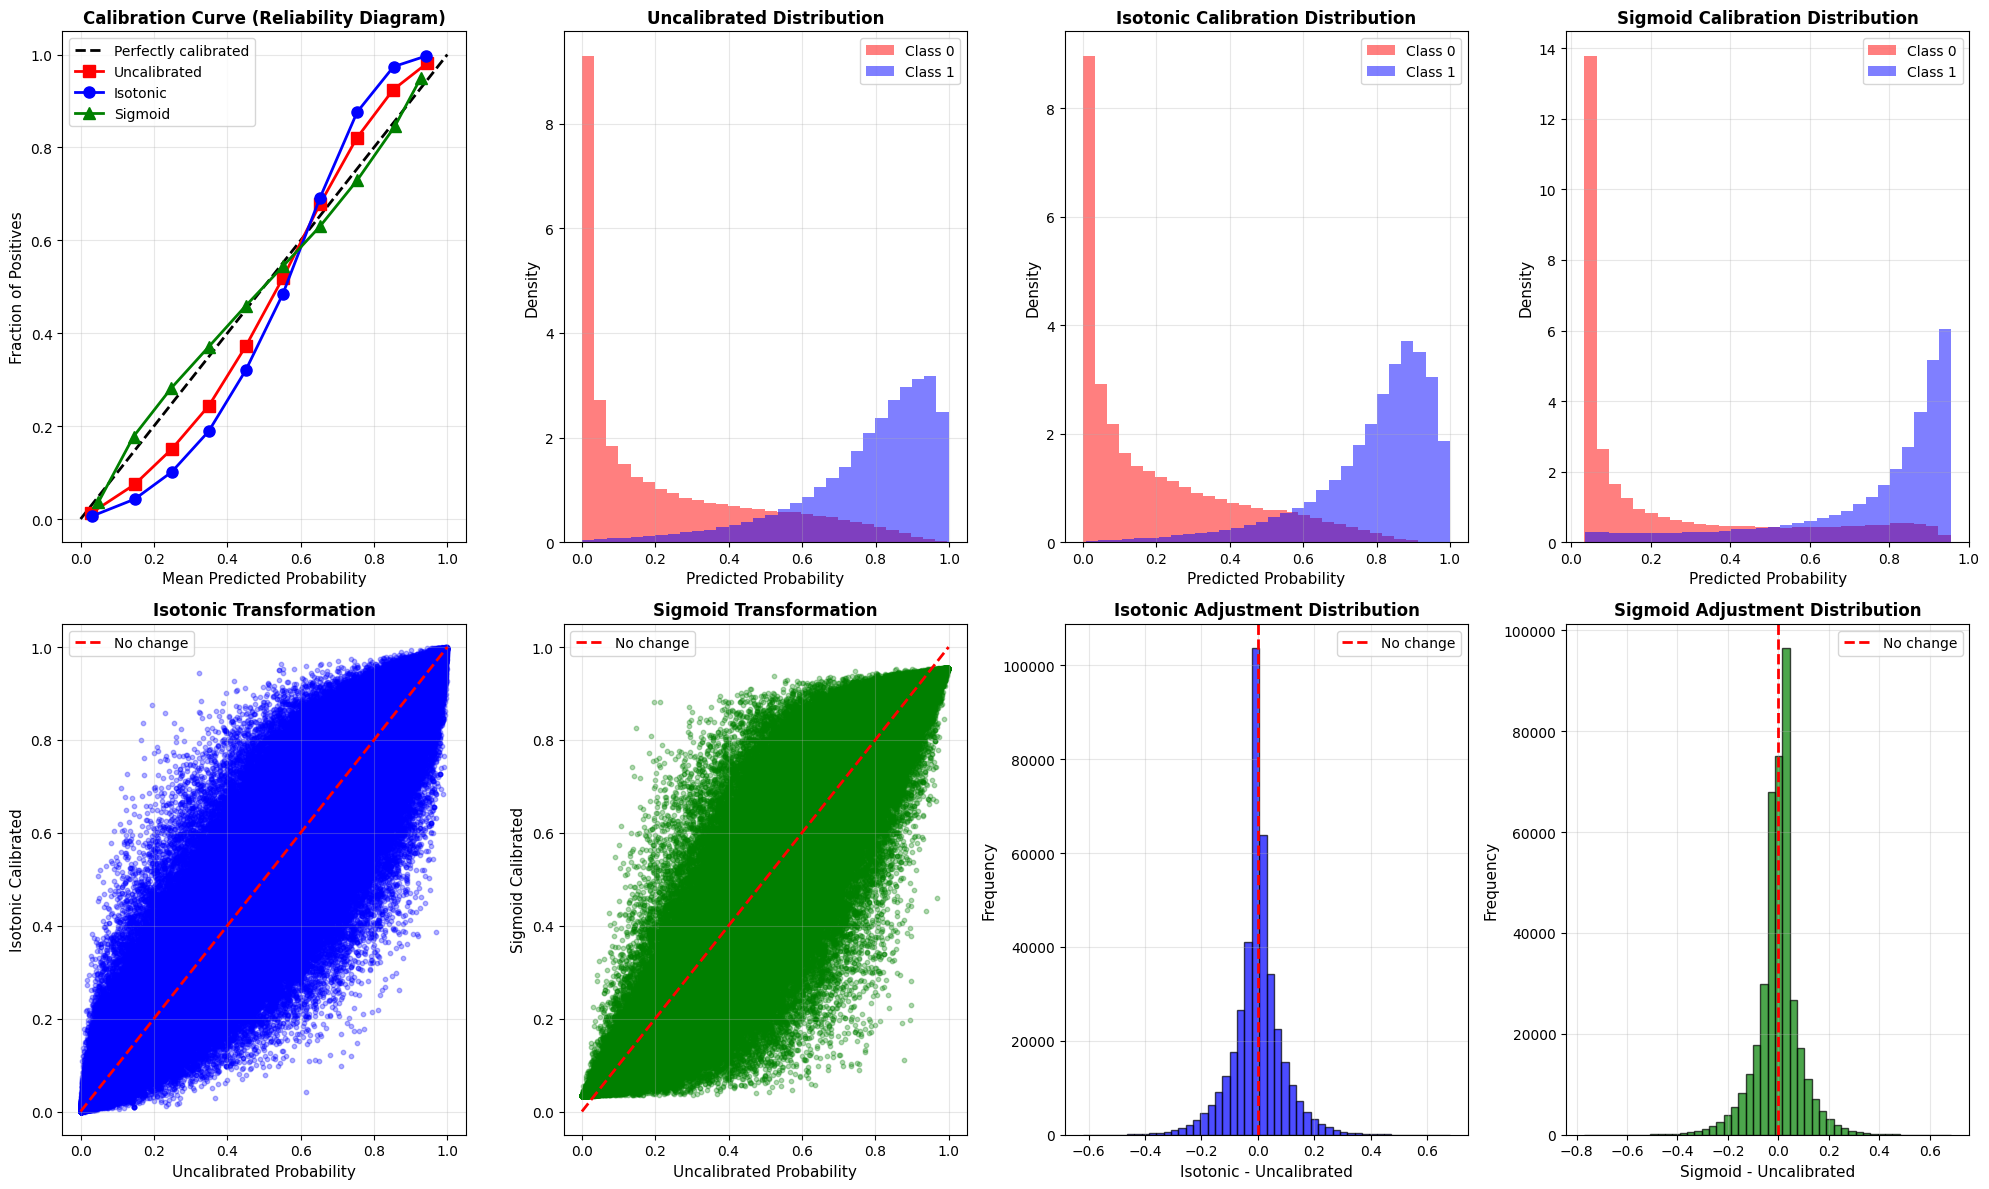

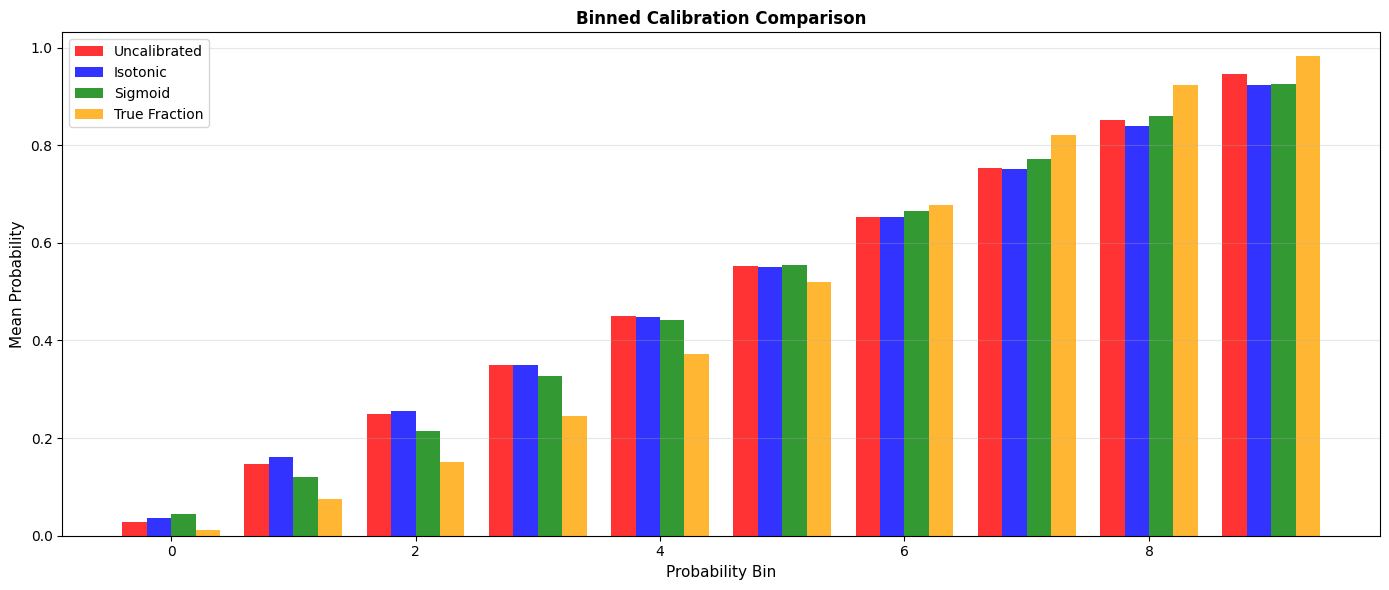


✓ Calibration analysis complete!
  - Plot saved as 'calibration_comparison_full.png'
  - Binned comparison saved as 'calibration_binned_comparison.png'


In [75]:
# ==================== METRICHE ====================
print("\n" + "="*50)
print("COMPARISON METRICS")
print("="*50)

# Brier Score (lower is better)
brier_uncal = brier_score_loss(y_test, uncalibrated_probs)
brier_isotonic = brier_score_loss(y_test, calibrated_probs_isotonic)
brier_sigmoid = brier_score_loss(y_test, calibrated_probs_sigmoid)
print(f"Brier Score (Uncalibrated): {brier_uncal:.4f}")
print(f"Brier Score (Isotonic):     {brier_isotonic:.4f}")
print(f"Brier Score (Sigmoid):      {brier_sigmoid:.4f}")

print(f"Improvement Isotonic: {((brier_uncal - brier_isotonic) / brier_uncal * 100):.2f}%")
print(f"Improvement Sigmoid:  {((brier_uncal - brier_sigmoid) / brier_uncal * 100):.2f}%")

# Log Loss (lower is better)
logloss_uncal = log_loss(y_test, uncalibrated_probs)
logloss_isotonic = log_loss(y_test, calibrated_probs_isotonic)
logloss_sigmoid = log_loss(y_test, calibrated_probs_sigmoid)
print(f"\nLog Loss (Uncalibrated): {logloss_uncal:.4f}")
print(f"Log Loss (Isotonic):     {logloss_isotonic:.4f}")
print(f"Log Loss (Sigmoid):      {logloss_sigmoid:.4f}")
print(f"Improvement Isotonic: {((logloss_uncal - logloss_isotonic) / logloss_uncal * 100):.2f}%")
print(f"Improvement Sigmoid:  {((logloss_uncal - logloss_sigmoid) / logloss_uncal * 100):.2f}%")

# ROC AUC (dovrebbe rimanere simile)
auc_uncal = roc_auc_score(y_test, uncalibrated_probs)
auc_isotonic = roc_auc_score(y_test, calibrated_probs_isotonic)
auc_sigmoid = roc_auc_score(y_test, calibrated_probs_sigmoid)
print(f"\nROC AUC (Uncalibrated): {auc_uncal:.4f}")
print(f"ROC AUC (Isotonic):     {auc_isotonic:.4f}")
print(f"ROC AUC (Sigmoid):      {auc_sigmoid:.4f}")

# Classification Metrics
print("\n" + "="*50)
print("CLASSIFICATION METRICS")
print("="*50)
print(f"{'Metric':<12} {'Uncalibrated':<15} {'Isotonic':<15} {'Sigmoid':<15}")
print("-" * 57)
print(f"{'Accuracy':<12} {metrics_uncalibrated['accuracy']:<15.4f} {metrics_calibrated_isotonic['accuracy']:<15.4f} {metrics_calibrated_sigmoid['accuracy']:<15.4f}")
print(f"{'Precision':<12} {metrics_uncalibrated['precision']:<15.4f} {metrics_calibrated_isotonic['precision']:<15.4f} {metrics_calibrated_sigmoid['precision']:<15.4f}")
print(f"{'Recall':<12} {metrics_uncalibrated['recall']:<15.4f} {metrics_calibrated_isotonic['recall']:<15.4f} {metrics_calibrated_sigmoid['recall']:<15.4f}")
print(f"{'F1-Score':<12} {metrics_uncalibrated['f1']:<15.4f} {metrics_calibrated_isotonic['f1']:<15.4f} {metrics_calibrated_sigmoid['f1']:<15.4f}")

# Esempi di probabilità
print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)
print("True | Uncalibrated | Isotonic  | Sigmoid")
print("-" * 48)
for i in range(10):
    print(f" {y_test[i]}   |    {uncalibrated_probs[i]:.4f}    |  {calibrated_probs_isotonic[i]:.4f}  |  {calibrated_probs_sigmoid[i]:.4f}")

# ==================== VISUALIZZAZIONI ====================
fig = plt.figure(figsize=(20, 12))

# 1. Calibration Curve (Reliability Diagram)
ax1 = plt.subplot(2, 4, 1)
fraction_of_positives_uncal, mean_predicted_value_uncal = calibration_curve(
    y_test, uncalibrated_probs, n_bins=10, strategy='uniform'
)
fraction_of_positives_isotonic, mean_predicted_value_isotonic = calibration_curve(
    y_test, calibrated_probs_isotonic, n_bins=10, strategy='uniform'
)
fraction_of_positives_sigmoid, mean_predicted_value_sigmoid = calibration_curve(
    y_test, calibrated_probs_sigmoid, n_bins=10, strategy='uniform'
)

plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated', linewidth=2)
plt.plot(mean_predicted_value_uncal, fraction_of_positives_uncal, 
         's-', label='Uncalibrated', markersize=8, linewidth=2, color='red')
plt.plot(mean_predicted_value_isotonic, fraction_of_positives_isotonic, 
         'o-', label='Isotonic', markersize=8, linewidth=2, color='blue')
plt.plot(mean_predicted_value_sigmoid, fraction_of_positives_sigmoid, 
         '^-', label='Sigmoid', markersize=8, linewidth=2, color='green')
plt.xlabel('Mean Predicted Probability', fontsize=11)
plt.ylabel('Fraction of Positives', fontsize=11)
plt.title('Calibration Curve (Reliability Diagram)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# 2. Distribuzione delle probabilità - Uncalibrated
ax2 = plt.subplot(2, 4, 2)
plt.hist(uncalibrated_probs[y_test == 0], bins=30, alpha=0.5, 
         label='Class 0', color='red', density=True)
plt.hist(uncalibrated_probs[y_test == 1], bins=30, alpha=0.5, 
         label='Class 1', color='blue', density=True)
plt.xlabel('Predicted Probability', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('Uncalibrated Distribution', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Distribuzione - Isotonic
ax3 = plt.subplot(2, 4, 3)
plt.hist(calibrated_probs_isotonic[y_test == 0], bins=30, alpha=0.5, 
         label='Class 0', color='red', density=True)
plt.hist(calibrated_probs_isotonic[y_test == 1], bins=30, alpha=0.5, 
         label='Class 1', color='blue', density=True)
plt.xlabel('Predicted Probability', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('Isotonic Calibration Distribution', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Distribuzione - Sigmoid
ax4 = plt.subplot(2, 4, 4)
plt.hist(calibrated_probs_sigmoid[y_test == 0], bins=30, alpha=0.5, 
         label='Class 0', color='red', density=True)
plt.hist(calibrated_probs_sigmoid[y_test == 1], bins=30, alpha=0.5, 
         label='Class 1', color='blue', density=True)
plt.xlabel('Predicted Probability', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('Sigmoid Calibration Distribution', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Scatter plot: Uncalibrated vs Isotonic
ax5 = plt.subplot(2, 4, 5)
plt.scatter(uncalibrated_probs, calibrated_probs_isotonic, alpha=0.3, s=10, color='blue')
plt.plot([0, 1], [0, 1], 'r--', label='No change', linewidth=2)
plt.xlabel('Uncalibrated Probability', fontsize=11)
plt.ylabel('Isotonic Calibrated', fontsize=11)
plt.title('Isotonic Transformation', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Scatter plot: Uncalibrated vs Sigmoid
ax6 = plt.subplot(2, 4, 6)
plt.scatter(uncalibrated_probs, calibrated_probs_sigmoid, alpha=0.3, s=10, color='green')
plt.plot([0, 1], [0, 1], 'r--', label='No change', linewidth=2)
plt.xlabel('Uncalibrated Probability', fontsize=11)
plt.ylabel('Sigmoid Calibrated', fontsize=11)
plt.title('Sigmoid Transformation', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 7. Difference in probabilities - Isotonic
ax7 = plt.subplot(2, 4, 7)
prob_diff_isotonic = calibrated_probs_isotonic - uncalibrated_probs
plt.hist(prob_diff_isotonic, bins=50, edgecolor='black', alpha=0.7, color='blue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No change')
plt.xlabel('Isotonic - Uncalibrated', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Isotonic Adjustment Distribution', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 8. Difference in probabilities - Sigmoid
ax8 = plt.subplot(2, 4, 8)
prob_diff_sigmoid = calibrated_probs_sigmoid - uncalibrated_probs
plt.hist(prob_diff_sigmoid, bins=50, edgecolor='black', alpha=0.7, color='green')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No change')
plt.xlabel('Sigmoid - Uncalibrated', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Sigmoid Adjustment Distribution', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('calibration_comparison_full.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== GRAFICO AGGIUNTIVO: Binned Comparison ====================
fig2 = plt.figure(figsize=(14, 6))

# Binned comparison
bins = np.linspace(0, 1, 11)
bin_indices = np.digitize(uncalibrated_probs, bins) - 1
bin_means_uncal = [uncalibrated_probs[bin_indices == i].mean() 
                   for i in range(len(bins)-1) if (bin_indices == i).sum() > 0]
bin_means_isotonic = [calibrated_probs_isotonic[bin_indices == i].mean() 
                      for i in range(len(bins)-1) if (bin_indices == i).sum() > 0]
bin_means_sigmoid = [calibrated_probs_sigmoid[bin_indices == i].mean() 
                     for i in range(len(bins)-1) if (bin_indices == i).sum() > 0]
bin_true = [pd.Series(y_test).iloc[bin_indices == i].mean() 
            for i in range(len(bins)-1) if (bin_indices == i).sum() > 0]

x_pos = np.arange(len(bin_means_uncal))
width = 0.2

ax = plt.subplot(1, 1, 1)
plt.bar(x_pos - 1.5*width, bin_means_uncal, width, label='Uncalibrated', alpha=0.8, color='red')
plt.bar(x_pos - 0.5*width, bin_means_isotonic, width, label='Isotonic', alpha=0.8, color='blue')
plt.bar(x_pos + 0.5*width, bin_means_sigmoid, width, label='Sigmoid', alpha=0.8, color='green')
plt.bar(x_pos + 1.5*width, bin_true, width, label='True Fraction', alpha=0.8, color='orange')
plt.xlabel('Probability Bin', fontsize=11)
plt.ylabel('Mean Probability', fontsize=11)
plt.title('Binned Calibration Comparison', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('calibration_binned_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Calibration analysis complete!")
print("  - Plot saved as 'calibration_comparison_full.png'")
print("  - Binned comparison saved as 'calibration_binned_comparison.png'")